In [1]:
import numpy as np
import scipy as sp
import gprob as gp

import matplotlib.pyplot as plt

np.random.seed(0)

This notebook illustrates information-theoretical calculations with random variables in gprob. There are two information-theoretical quantities whose computation is built in, `entropy` and `dkl` (the Kullback-Leibler divergence), while other quantities, such as cross-entropy or mutual information, can be derived as shown below.

# Quantifying the information

## Entropy

The entropy is a scalar measure of the uncertainty of the outcomes of a random variable. For a continuous variable $x$, the entropy is defined as 
\begin{equation*}
H(x)=-\int p_x(v)\log p_x(v) \,dv,
\end{equation*}
where $\log$ is the natural logarithm, $p_x(v)$ is the probability density of $x$ to take the value $v,$ and the integration is over the whole space of values.

In gprob, the entropy can be computed as follows:

In [2]:
x = gp.normal()
x.entropy()  # alternatively, gp.entropy(x)

1.4189385332046727

One interpretation of the entropy is the following. If the value space is discretized into small volume elements $\Delta v$, the average number of bits $n$ that is required to store the information about one realization of $x$ is approximately
\begin{equation*}
n=\left(H(x)-\log(\Delta v)\right)/\log(2).
\end{equation*} 

For our univariate variable with the descretization step of 1e-2, this value is

In [3]:
(x.entropy() - np.log(1e-2)) / np.log(2)

8.690951774955366

Entropy is a additive for independent variables.

In [4]:
x = gp.normal(0, 2)
y = gp.normal(0, 25)

xy = gp.stack([x, y])

print(xy.entropy())
print(x.entropy() + y.entropy())

4.7938885691234185
4.793888569123418


The entropy of degenerate random variables, whose non-zero probability outcomes do not cover the whole value space, equals $-\infty$ according to our definition.

In [5]:
x = gp.normal()
xx = gp.stack([x, x])  # For this variable, (0, v) is impossible if v!=0.

xx.entropy()

-inf

However, because of the logarithm in its definition, the entropy decreases fairly slowly as the distribution approaches degeneracy.

In [6]:
xx_ = gp.stack([x, x + 1e-7 * gp.normal()])

xx_.entropy()

-13.280618383264073

## Kullback-Leibler divergence

The Kullback-Leibler divergence is a measure of dissimilarity between the probability densities $p_x(v)$ and $p_y(v)$ of two random variables $x$ and $y$ to take the value $v$, which is defined as
\begin{equation*}
D_\mathrm{KL}\big(x, y\big)=\int p_x(v)\log \big(p_x(v)/p_y(v)\big) \,dv.
\end{equation*}
Another way to denote the same quantity would be $D_\mathrm{KL}\big(p_x||p_y\big)$.

For example, we can calculate the divergence between two scalar variables as follows: 

In [7]:
x = gp.normal()
y = gp.normal() + x

gp.dkl(x, y)

0.0965735902799727

The divergence is unrelated to correlation - when two variables have identical distributions, their divergences from another variable are always identical.

In [8]:
z = gp.normal(0, 2)
gp.dkl(x, z)  # == gp.dkl(x, y), while x is correlated with y but not z.

0.0965735902799727

The divergence between variables is not defined when the spaces of their outcomes are not identical, i.e. when the variables have different size or shape.

In [9]:
x = gp.normal(size=1)  # shape (1,)
y = gp.normal(size=2)  # shape (2,)

try:
    gp.dkl(x, y)
except ValueError as e:
    print(e)

The input variables have mismatching shapes: (1,) and (2,).


## Other quantities

Other information-theoretical quantities can be expressed via the entropy and $D_\mathrm{KL}$, including the mutual information, 
\begin{equation*}
I(x, y)=D_\mathrm{KL}\big(xy, x \otimes y\big),
\end{equation*}
cross-entropy, 
\begin{equation*}
H(x, y)=\int p_x(v)\log p_y(v) \,dv,
\end{equation*}
and conditional entropy,
\begin{equation*}
H(x | y)= H(xy) - H(y).
\end{equation*}

In [10]:
def mutual_information(x, y):
    """D_KL(p_xy || p_x ⮾ p_y) - mutual information between ``x`` and ``y``."""
    x, y = x.ravel(), y.ravel()
    xy = gp.concatenate([x, y])
    xy_prod = gp.concatenate([x, y.icopy()])
    return gp.dkl(xy, xy_prod)


def cross_entropy(x, y):
    """H(x, y) - cross entropy of ``x`` relative to ``y``."""
    return gp.entropy(x) + gp.dkl(x, y)


def conditional_entropy(x, y):
    """H(x | y) - conditional entropy of ``x`` given ``y``."""
    xy = gp.concatenate([x.ravel(), y.ravel()])
    return gp.entropy(xy) - gp.entropy(y)

The cross entropy can be interpreted as the logarithmic probability density of one variable averaged over samples from the other:

In [11]:
def r(n, m):
    """A zero-mean random ``n`` by ``m`` matrix."""
    return 2 * np.random.rand(n, m) - 1

x = [1, 2] + r(2, 2) @ gp.normal(size=2)
y = [0.1, -0.2] + r(2, 2) @ gp.normal(size=2)

xs = x.sample(10**6)

print(f"<-log p_y>_x:  {-np.mean(y.logp(xs))}")
print(f"Cross entropy: {cross_entropy(x, y)}")

<-log p_y>_x:  10.40000659730859
Cross entropy: 10.396101241792543


The conditional entropy of Gaussian random variables is the same as the entropy of the variables conditioned on any value, because the value only affects the mean, but not the distribution around the mean of the conditioned variable. (For non-Gaussian variables, one can only say the conditional entropy is the entropy of the conditioned variable averaged over the probability density of the condition.)

We can illustrate this by calculating the conditional entropy in two different ways:

In [12]:
xy = r(5, 5) @ gp.normal(size=5)  # A correlated 5-dimensional distribution.
x, y = xy[:3], xy[3:] 

print(conditional_entropy(x, y))
print(gp.entropy(x | y))            # x | y is another way of writing x | {y: 0}

3.018444208939146
3.0184442089391457


If fixing the value of one variable determines a component of another completely, their mutual information is $\infty$, and the conditional entropy is $-\infty$.

In [13]:
x = gp.normal()
y = x + gp.normal()

xy = gp.stack([x, y])

print(mutual_information(xy, x))
print(conditional_entropy(xy, x))

inf
-inf


# Example: bits transmitted through a noisy channel

Suppose that two parties communicate via Gaussian-distributed random signals. One party sends the signals, and the other receives them. In the process of transmission, the signals are corrupted by noise, which we suppose to be Gaussian-distributed. A communication channel with such noise properties is called the Additive White Gaussian Noise (AWGN) channel. We will find how many bits on average are recovered by the receiver in this setting.

First, we construct a model of the channel:

In [14]:
x = gp.normal(0, 3.5)   # The distribution of the sent signals.
w = gp.normal(0, 1e-8)  # The added noise.
y = x + w               # The distribution of the received signals.

Theoretically, the communication capacity of the channel is given by the mutual information between the sent and received states:

In [15]:
mutual_information(x, y) / np.log(2)  # capacity in bits / trial

14.191389839453825

We can compare this number to the result of a numerical experiment. To count the transmitted bits, we first setup some helper functions:

In [16]:
def bits32(x):
    """Prints the first 32 bits in the floating-point binary representation 
    of the number ``x`` ∈ [0, 1)."""
    return f"{np.uint32(x * 2**32):0>32b}"


def nmb32(x, y):
    """Counts the number of matching most-significant bits in the floating-point
    binary representations of ``x`` and ``y`` ∈ [0, 1)."""
    
    n = 0
    for s1, s2 in zip(bits32(x), bits32(y)):
        if s1 != s2:
            break
        n += 1

    return n


def decode(x):
    """Decodes a sample from zero-mean unit-variance Gaussian distribution 
    into a value uniformly distributed between 0 and 1."""
    return (1 + sp.special.erf(x / np.sqrt(2))) / 2

The decoding function here maps Gaussian distributions to uniform distributions, where all digits of a number are independent from each other.
For the experiment, we sample the realizations of the transmission, and count the matching bits in the decoded signals:

In [17]:
ns = 10 ** 5
xs, ys = gp.sample([x, y], ns)

xsd = decode(xs / x.std())
ysd = decode(ys / y.std())

nbits = np.mean([nmb32(x_, y_) - 1 for x_, y_ in zip(xsd, ysd)])  
# -1 is the correction for the expected matching length 
# of two independent completely random binary sequences.

print(f"The average number of received bits: {nbits}")

The average number of received bits: 14.21


The decoded samples are uniformly distributed, which means that their representation cannot be compressed further.

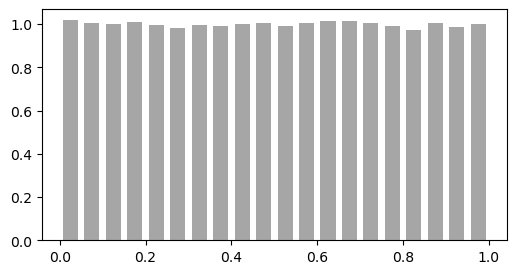

In [18]:
plt.figure(figsize=(6, 3.))
plt.hist(ysd, rwidth=0.7, density=True, bins=20, color="gray", alpha=0.7);

Having a certain average number of correctly received bits tells, in particular, how many bits it makes sense to use for the storage of the received signals. (One can always choose to record the received signals with higher precision, but the least significant digits will be just meaningless noise.)

Now suppose that the receiving party assumes a wrong distribution of the transmitted signals (we will call this assumption $z$). One penalty this would incur for the receiver is that he or she has to store more bits of the decoded result so as not to lose the information.

In [19]:
z = gp.normal(0, 1e3)

xsd_ = decode(xs / z.std())
ysd_ = decode(ys / (z + w).std())

nbits_ = np.mean([nmb32(x_, y_) - 1 for x_, y_ in zip(xsd_, ysd_)])  
# -1 is the correction for the expected matching length 
# of two independent completely random binary sequences.

print(f"The average number of received bits: {nbits_}")
print(f"The extra bits required for storage: {nbits_ - nbits}")

The average number of received bits: 17.56514
The extra bits required for storage: 3.3551399999999987


The extra number of bits required for the storage is given by the divergence between the true and the assumed distributions of the signal:

In [20]:
gp.dkl(x, z) / np.log(2)

3.3603918771793153

(This is approximately true in our example, where the noise variance is much smaller than the signal variance.)